Setup & Import Data

In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

# 1. SETUP & INITIALIZATION
# Inisialisasi W&B untuk tracking eksperimen
run = wandb.init(project="nlp-sentiment-analysis", name="optimized-logreg-tfidf")

# Download library NLTK untuk preprocessing tingkat lanjut
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 2. LOAD STABLE DATASET (TFDS)
print("Sedang mengunduh dataset IMDB dari TensorFlow Datasets...")
ds = tfds.load('imdb_reviews', split='train', as_supervised=True)

# Konversi ke Pandas DataFrame
train_data = list(tfds.as_numpy(ds))
df = pd.DataFrame(train_data, columns=['review', 'label'])
df['review'] = df['review'].str.decode("utf-8")
df['label'] = df['label'].map({0: 'neg', 1: 'pos'})

# Ambil 10.000 sampel untuk efisiensi komputasi di kelas
df = df.sample(10000, random_state=42)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mushab-a-fathin (mushab-a-fathin-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.J2TAXQ_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.J2TAXQ_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


Text Cleaning

In [2]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def advanced_clean(text):
    # Case folding & Hapus karakter spesial
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)

    # Tokenization, Stopwords Removal, & Lemmatization
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

print("Sedang melakukan pembersihan teks (Cleaning & Lemmatization)...")
df['review_processed'] = df['review'].apply(advanced_clean)

Sedang melakukan pembersihan teks (Cleaning & Lemmatization)...


Vectorization

In [3]:
# Menggunakan Bigrams (ngram_range=(1,2)) agar AI paham konteks kata seperti "not good"
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['review_processed'])
y = df['label']

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training & Evaluation

In [4]:
# Logistic Regression cenderung lebih stabil untuk fitur teks berdimensi tinggi
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL OPTIMALISASI ---")
print(f"Akurasi Akhir: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Log metrik ke W&B
wandb.log({
    "Accuracy": acc,
    "Model_Type": "Logistic Regression",
    "Vectorization": "TF-IDF + Bigrams",
    "Vocab_Size": 10000
})


--- HASIL OPTIMALISASI ---
Akurasi Akhir: 0.8790

Classification Report:
              precision    recall  f1-score   support

         neg       0.88      0.88      0.88      1010
         pos       0.88      0.88      0.88       990

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



Visualisasi Confusion Matrix

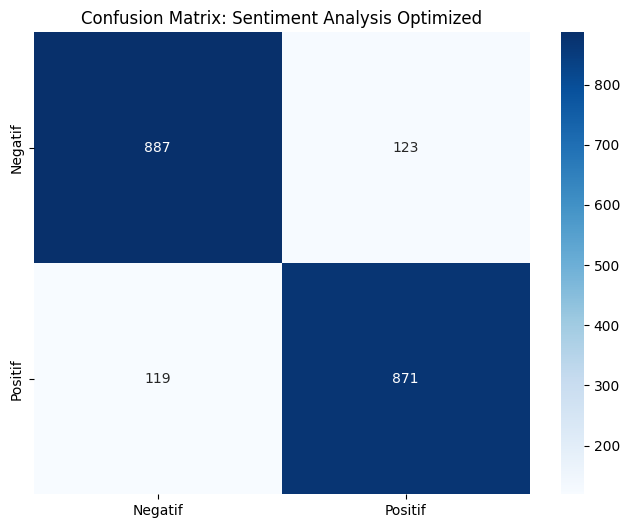

Accuracy,▁
Vocab_Size,▁
Accuracy,0.879
Model_Type,Logistic Regression
Vectorization,TF-IDF + Bigrams
Vocab_Size,10000


In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix: Sentiment Analysis Optimized')
plt.show()

wandb.finish()